## Lab 3

### 1. Library Imports

In [1]:
# tensorflow must be imported before pandas/sklearn, otherwise the MKL that they
# load first breaks TF's GPU variable allocation and the kernel segfaults
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# to display plots in Jupyter notebook
%matplotlib inline

plt.rcParams['font.size'] = '12'

np.random.seed(42)
tf.random.set_seed(42)

I0000 00:00:1786365321.256649  419767 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786365321.283457  419767 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 2. Task 1: Loading the Wine Data

`wine.data` has no header row, so the 14 column names are taken from `wine.names`: the
class ID followed by the 13 attributes.

In [2]:
column_names = ["class", "alcohol", "malic acid", "ash", "alcalinity of ash",
                "magnesium", "total phenols", "flavanoids", "nonflavanoid phenols",
                "proanthocyanins", "color intensity", "hue", "OD280/OD315", "proline"]

wine = pd.read_csv("wine.data", header=None, names=column_names)
wine.head()

,class,alcohol,malic acid,ash,alcalinity of ash,magnesium,total phenols,flavanoids,nonflavanoid phenols,proanthocyanins,color intensity,hue,OD280/OD315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
wine["class"].value_counts().sort_index()

class
1    59
2    71
3    48
Name: count, dtype: int64

In [4]:
wine.describe().T

,count,mean,std,min,25%,50%,75%,max
class,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity of ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


The three classes are reasonably balanced (59/71/48). The magnitudes of the attributes
are not: `proline` runs into the hundreds and `magnesium` into the low hundreds, while
`hue` and `nonflavanoid phenols` sit below 2. Left alone, the two large attributes would
dominate every dot product in the first layer, so the features are standardised below.

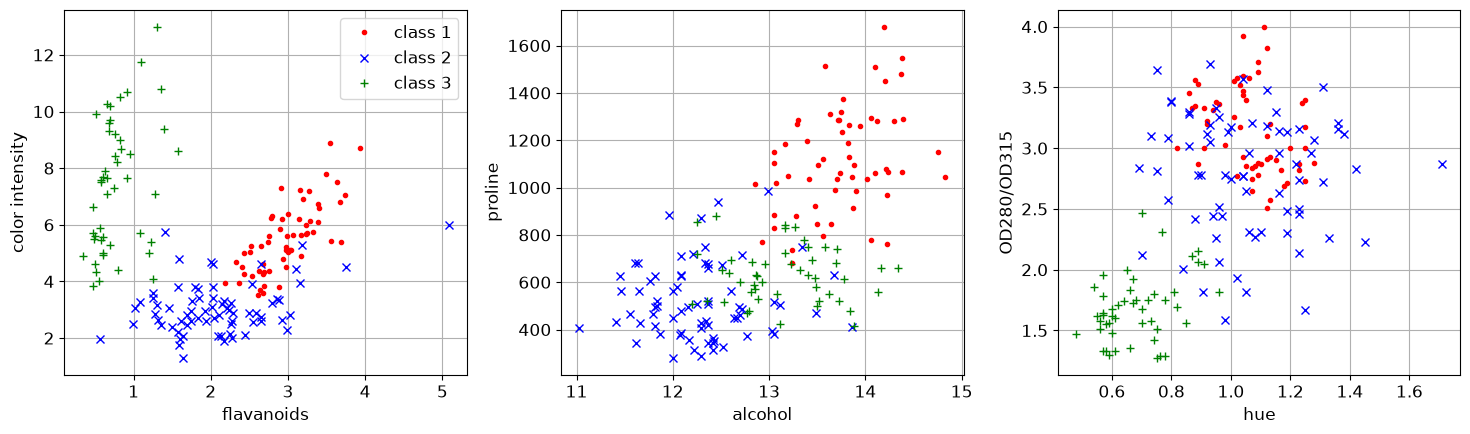

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pairs = [("flavanoids", "color intensity"), ("alcohol", "proline"),
         ("hue", "OD280/OD315")]
for ax, (xcol, ycol) in zip(axes, pairs):
    for class_id, marker in zip([1, 2, 3], ["r.", "bx", "g+"]):
        subset = wine[wine["class"] == class_id]
        ax.plot(subset[xcol], subset[ycol], marker, label=f"class {class_id}")
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(True)
axes[0].legend()
plt.tight_layout()
plt.show()

No single pair of attributes separates the three cultivars cleanly, but each pair gets
part of the way there, which is what makes this an easy problem for a small MLP.

### 3. Task 1: Preprocessing and Splitting

The class IDs go from 1, 2, 3 to 0, 1, 2 so they can index the softmax output directly.
The 80/20 split is stratified so all three classes keep their proportions, and the
scaler is fitted on the training set only.

In [6]:
y = wine["class"].values - 1
X = wine.drop(columns="class").values.astype("float32")

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype("float32")
X_valid = scaler.transform(X_valid).astype("float32")

print(X_train.shape, X_valid.shape)

(142, 13) (36, 13)


### 4. Task 1: model1, 3 Hidden Layers

Both wine models share the same shape apart from the number of hidden layers, so the
build and fit steps are factored out. Nadam is the optimizer and `EarlyStopping` with
`restore_best_weights=True` rolls the model back to its best epoch, so the 500 epoch
budget is an upper bound rather than the number actually run.

In [7]:
def build_wine_model(n_hidden):
    tf.random.set_seed(42)
    model = tf.keras.Sequential([tf.keras.layers.InputLayer(shape=[13])])
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(5, activation="gelu"))
    model.add(tf.keras.layers.Dense(3, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Nadam(learning_rate=0.01),
                  metrics=["accuracy"])
    return model


def fit_wine_model(model, class_weight=None):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        patience=50, restore_best_weights=True)
    return model.fit(X_train, y_train, epochs=500,
                     validation_data=(X_valid, y_valid),
                     class_weight=class_weight,
                     callbacks=[early_stopping_cb], verbose=0)

In [8]:
model1 = build_wine_model(3)
model1.summary()

I0000 00:00:1786365323.510774  419767 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9216 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148 (592.00 B)

 Trainable params: 148 (592.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
history1 = fit_wine_model(model1)
print("epochs actually run:", len(history1.history["loss"]))

I0000 00:00:1786365324.800752  419849 service.cc:153] XLA service 0x78c2200325a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786365324.800770  419849 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.23.1)
I0000 00:00:1786365324.826504  419849 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786365324.877780  419849 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1786365324.884345  419849 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2164__.14


I0000 00:00:1786365326.306895  419849 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1786365326.379200  419850 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2164__.14


epochs actually run: 176


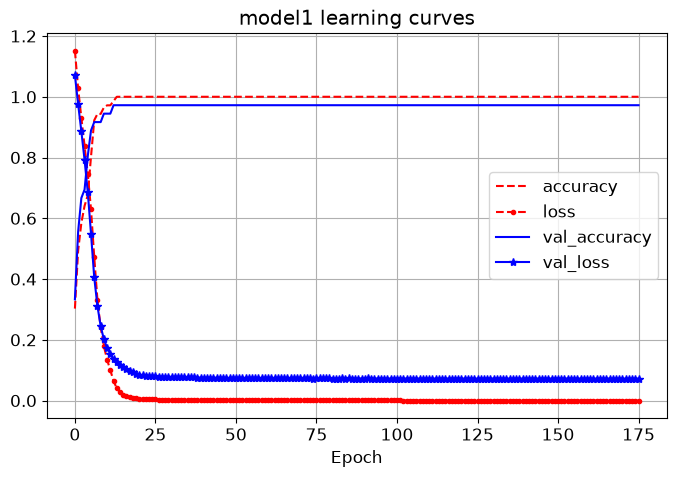

In [10]:
pd.DataFrame(history1.history).plot(figsize=(8, 5), grid=True, xlabel="Epoch",
                                    style=["r--", "r--.", "b-", "b-*"],
                                    title="model1 learning curves")
plt.show()

The confusion matrices below use `np.argmax` on the softmax output, since a Keras
classifier returns class probabilities rather than class IDs.

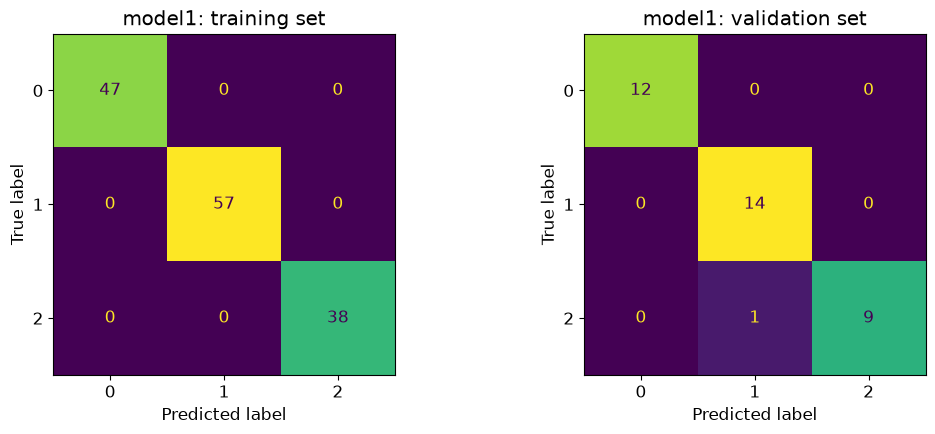

In [11]:
def plot_confusion_matrices(model, title):
    y_train_pred = np.argmax(model.predict(X_train, verbose=0), axis=1)
    y_valid_pred = np.argmax(model.predict(X_valid, verbose=0), axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axes[0],
                                            colorbar=False)
    ConfusionMatrixDisplay.from_predictions(y_valid, y_valid_pred, ax=axes[1],
                                            colorbar=False)
    axes[0].set_title(f"{title}: training set")
    axes[1].set_title(f"{title}: validation set")
    plt.tight_layout()
    plt.show()


plot_confusion_matrices(model1, "model1")

In [12]:
def evaluate_wine_model(model, name):
    train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
    valid_loss, valid_acc = model.evaluate(X_valid, y_valid, verbose=0)
    return {"model": name, "train accuracy": train_acc,
            "validation accuracy": valid_acc, "validation loss": valid_loss}


scores = [evaluate_wine_model(model1, "model1 (3 hidden layers)")]
scores[-1]

{'model': 'model1 (3 hidden layers)',
 'train accuracy': 1.0,
 'validation accuracy': 0.9722222089767456,
 'validation loss': 0.07177189737558365}

### 5. Task 1: model2, 4 Hidden Layers

In [13]:
model2 = build_wine_model(4)
history2 = fit_wine_model(model2)
print("epochs actually run:", len(history2.history["loss"]))

I0000 00:00:1786365339.215937  419848 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16302__.15


I0000 00:00:1786365339.920089  419850 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_16302__.15


epochs actually run: 61


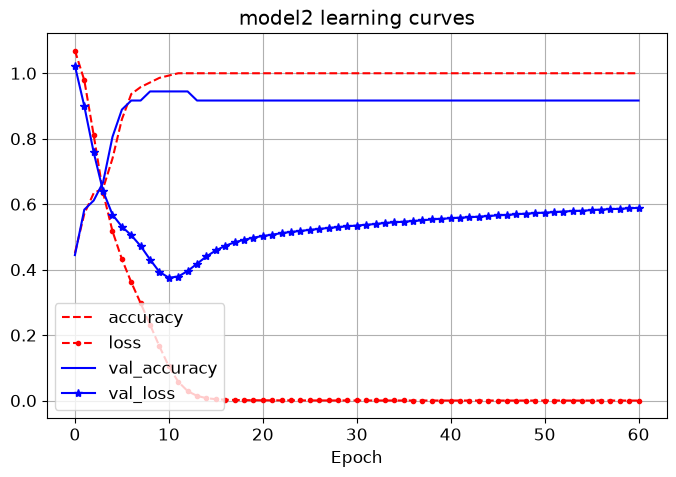

In [14]:
pd.DataFrame(history2.history).plot(figsize=(8, 5), grid=True, xlabel="Epoch",
                                    style=["r--", "r--.", "b-", "b-*"],
                                    title="model2 learning curves")
plt.show()

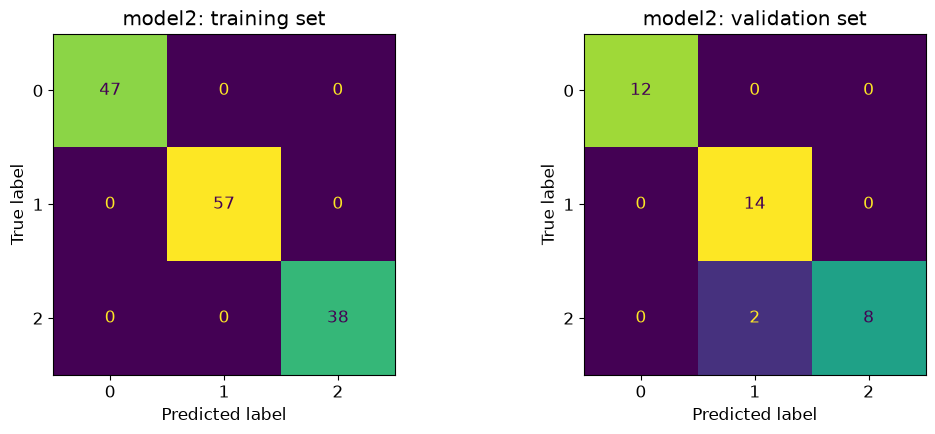

In [15]:
plot_confusion_matrices(model2, "model2")

In [16]:
scores.append(evaluate_wine_model(model2, "model2 (4 hidden layers)"))
scores[-1]

{'model': 'model2 (4 hidden layers)',
 'train accuracy': 1.0,
 'validation accuracy': 0.9444444179534912,
 'validation loss': 0.3753338158130646}

### 6. Task 1: model3, Class Weights

`model3` has the same 3 hidden layers as `model1` and differs only in the `class_weight`
passed to `fit()`. The weights are the balanced ones, `n_samples / (n_classes *
n_samples_in_class)`, so the smallest class (class 2) gets weighted up and the largest
(class 1) down.

In [17]:
weights = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_train)
class_weight = {i: w for i, w in enumerate(weights)}
class_weight

{0: np.float64(1.0070921985815602),
 1: np.float64(0.8304093567251462),
 2: np.float64(1.2456140350877194)}

In [18]:
model3 = build_wine_model(3)
history3 = fit_wine_model(model3, class_weight=class_weight)
print("epochs actually run:", len(history3.history["loss"]))

I0000 00:00:1786365346.772907  419852 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22918__.14


I0000 00:00:1786365347.718692  419849 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22918__.14


epochs actually run: 65


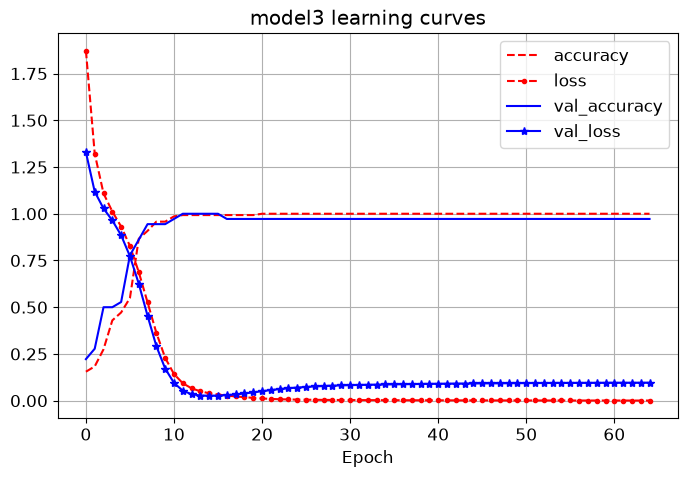

In [19]:
pd.DataFrame(history3.history).plot(figsize=(8, 5), grid=True, xlabel="Epoch",
                                    style=["r--", "r--.", "b-", "b-*"],
                                    title="model3 learning curves")
plt.show()

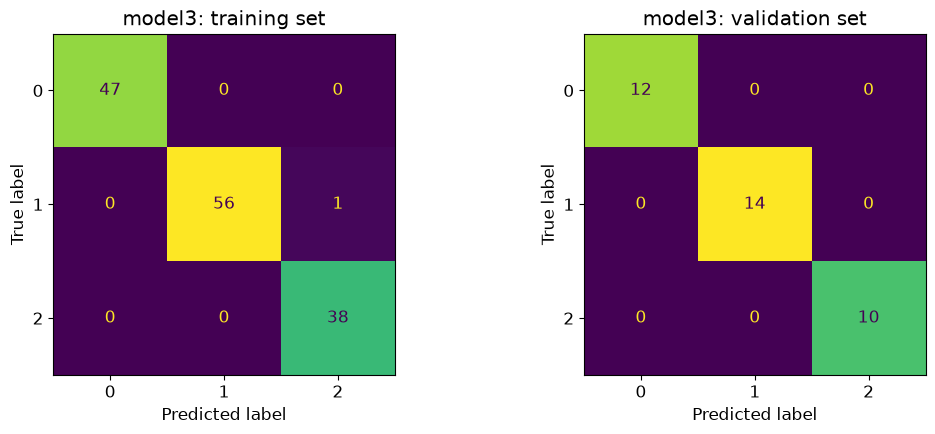

In [20]:
plot_confusion_matrices(model3, "model3")

In [21]:
scores.append(evaluate_wine_model(model3, "model3 (3 layers, class weights)"))
pd.DataFrame(scores).set_index("model").round(4)

,train accuracy,validation accuracy,validation loss
model,,,
model1 (3 hidden layers),1.000,0.9722,0.0718
model2 (4 hidden layers),1.000,0.9444,0.3753
"model3 (3 layers, class weights)",0.993,1.0000,0.0260


All three models clear the 90% validation accuracy the lab sheet asks for, and all three
fit the training set essentially perfectly, which is expected with 142 training instances
and 13 informative features.

`model3` comes out best: adding balanced class weights takes validation accuracy to 100%
and cuts validation loss to 0.026, the slight improvement over `model1` the sheet predicts.
The weights are mild (0.83 to 1.25) because the classes are only mildly imbalanced, but
they are enough to stop the largest class dominating the gradient.

`model2` is the exception. The lab sheet suggests the fourth hidden layer should improve
things a little, and here it does the opposite: validation accuracy drops from 97.2% to
94.4% and validation loss jumps from 0.072 to 0.375. Two things are worth separating. The
accuracy gap is one instance, since the validation set holds only 36 wines and each one is
worth 2.8 points, so that part is noise. The loss gap is not noise: `model2` stopped after
61 epochs against 176 for `model1`, so early stopping cut it off much sooner, and it is
far less confident about the predictions it gets right. Stacking a fourth 5-neuron layer
makes a narrow network deeper without making it wider, so the gradient has one more
bottleneck to squeeze through on a very small training set.

### 7. Task 2: Loading the Wine Quality Data

In [22]:
wq = pd.read_csv("winequality-white.csv", sep=";")
wq.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [23]:
wq.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,4898.0,6.854788,0.843868,3.80000,6.300000,6.80000,7.3000,14.20000
volatile acidity,4898.0,0.278241,0.100795,0.08000,0.210000,0.26000,0.3200,1.10000
citric acid,4898.0,0.334192,0.121020,0.00000,0.270000,0.32000,0.3900,1.66000
residual sugar,4898.0,6.391415,5.072058,0.60000,1.700000,5.20000,9.9000,65.80000
chlorides,4898.0,0.045772,0.021848,0.00900,0.036000,0.04300,0.0500,0.34600
free sulfur dioxide,4898.0,35.308085,17.007137,2.00000,23.000000,34.00000,46.0000,289.00000
total sulfur dioxide,4898.0,138.360657,42.498065,9.00000,108.000000,134.00000,167.0000,440.00000
density,4898.0,0.994027,0.002991,0.98711,0.991723,0.99374,0.9961,1.03898
pH,4898.0,3.188267,0.151001,2.72000,3.090000,3.18000,3.2800,3.82000
sulphates,4898.0,0.489847,0.114126,0.22000,0.410000,0.47000,0.5500,1.08000


In [24]:
wq["quality"].value_counts().sort_index()

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64

4898 white wines, 11 physicochemical features, and a quality score from 3 to 9. The
scores pile up on 5, 6 and 7, with only 20 wines at 3 and 5 at 9, so the extremes are
barely represented. The features again have very different magnitudes (`total sulfur
dioxide` in the hundreds against `chlorides` near 0.05), so they are standardised the
same way as in task 1.

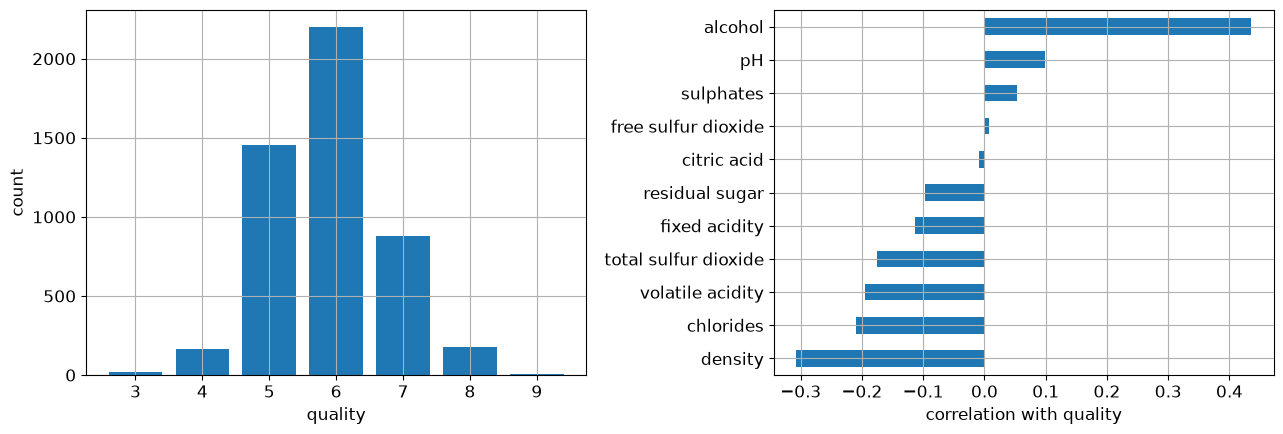

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(wq["quality"], bins=np.arange(2.5, 10.5), rwidth=0.8)
axes[0].set_xlabel("quality")
axes[0].set_ylabel("count")
axes[0].grid(True)

wq.corr()["quality"].drop("quality").sort_values().plot.barh(ax=axes[1], grid=True)
axes[1].set_xlabel("correlation with quality")
plt.tight_layout()
plt.show()

Alcohol is the feature most strongly correlated with quality and density the most
negatively correlated, but nothing is above about 0.45 in absolute value, so no single
feature explains the score on its own.

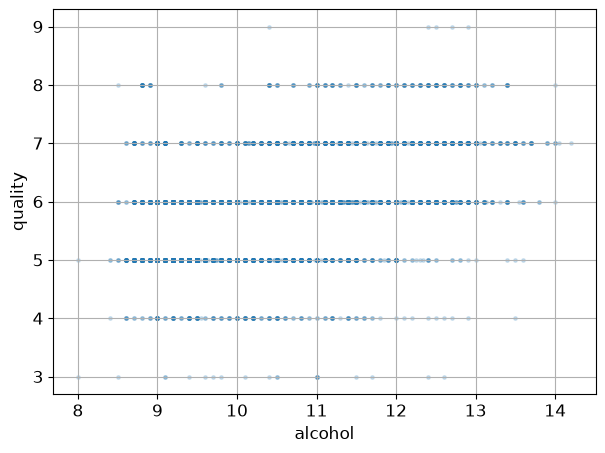

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(wq["alcohol"], wq["quality"], s=6, alpha=0.2)
ax.set_xlabel("alcohol")
ax.set_ylabel("quality")
ax.grid(True)
plt.show()

### 8. Task 2: Preprocessing and Splitting

In [27]:
y_q = wq["quality"].values.astype("float32")
X_q = wq.drop(columns="quality").values.astype("float32")

X_train_q, X_valid_q, y_train_q, y_valid_q = train_test_split(
    X_q, y_q, test_size=0.2, random_state=42)

scaler_q = StandardScaler()
X_train_q = scaler_q.fit_transform(X_train_q).astype("float32")
X_valid_q = scaler_q.transform(X_valid_q).astype("float32")

print(X_train_q.shape, X_valid_q.shape)

(3918, 11) (980, 11)


### 9. Task 2: model4, 8 ReLU Hidden Layers

The loss is MSE and the metric is MAE, so `evaluate()` returns both. The output layer is
a single linear neuron, i.e. the quality score is predicted directly.

In [28]:
def fit_quality_model(model):
    model.compile(loss="mse",
                  optimizer=tf.keras.optimizers.Nadam(learning_rate=0.001),
                  metrics=["mae"])
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        patience=30, restore_best_weights=True)
    return model.fit(X_train_q, y_train_q, epochs=500,
                     validation_data=(X_valid_q, y_valid_q),
                     callbacks=[early_stopping_cb], verbose=0)


def evaluate_quality_model(model, name):
    train_mse, train_mae = model.evaluate(X_train_q, y_train_q, verbose=0)
    valid_mse, valid_mae = model.evaluate(X_valid_q, y_valid_q, verbose=0)
    return {"model": name, "train MSE": train_mse, "train MAE": train_mae,
            "validation MSE": valid_mse, "validation MAE": valid_mae}

In [29]:
tf.random.set_seed(42)

model4 = tf.keras.Sequential([tf.keras.layers.InputLayer(shape=[11])])
for _ in range(8):
    model4.add(tf.keras.layers.Dense(5, activation="relu",
                                     kernel_initializer="he_normal"))
model4.add(tf.keras.layers.Dense(1))

model4.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history4 = fit_quality_model(model4)
print("epochs actually run:", len(history4.history["loss"]))

I0000 00:00:1786365354.759652  419850 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31555__.15


I0000 00:00:1786365356.206590  419848 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_31555__.15


epochs actually run: 121


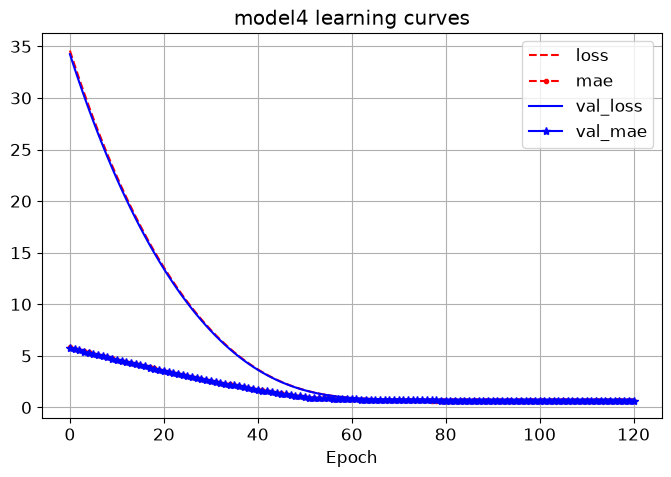

In [31]:
pd.DataFrame(history4.history).plot(figsize=(8, 5), grid=True, xlabel="Epoch",
                                    style=["r--", "r--.", "b-", "b-*"],
                                    title="model4 learning curves")
plt.show()

In [32]:
quality_scores = [evaluate_quality_model(model4, "model4 (8 ReLU)")]
quality_scores[-1]

{'model': 'model4 (8 ReLU)',
 'train MSE': 0.7864147424697876,
 'train MAE': 0.6720449328422546,
 'validation MSE': 0.7754641175270081,
 'validation MAE': 0.6745520234107971}

### 10. Task 2: model5, ReLU then tanh with a Rescaling Layer

The first 4 hidden layers keep ReLU, the last 4 and the output layer use tanh, and a
`Rescaling` layer maps the output. tanh gives values in $[-1, 1]$, and the target range
is $[3, 9]$, whose midpoint is 6 and half-width is 3, so the mapping is
$y = 3t + 6$, i.e. `scale=3.0` and `offset=6.0`.

In [33]:
tf.random.set_seed(42)

model5 = tf.keras.Sequential([tf.keras.layers.InputLayer(shape=[11])])
for _ in range(4):
    model5.add(tf.keras.layers.Dense(5, activation="relu",
                                     kernel_initializer="he_normal"))
for _ in range(4):
    model5.add(tf.keras.layers.Dense(5, activation="tanh"))
model5.add(tf.keras.layers.Dense(1, activation="tanh"))
model5.add(tf.keras.layers.Rescaling(scale=3.0, offset=6.0))

model5.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 5)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history5 = fit_quality_model(model5)
print("epochs actually run:", len(history5.history["loss"]))

I0000 00:00:1786365394.166099  419851 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_117859__.15


I0000 00:00:1786365395.821117  419848 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_117859__.15


epochs actually run: 159


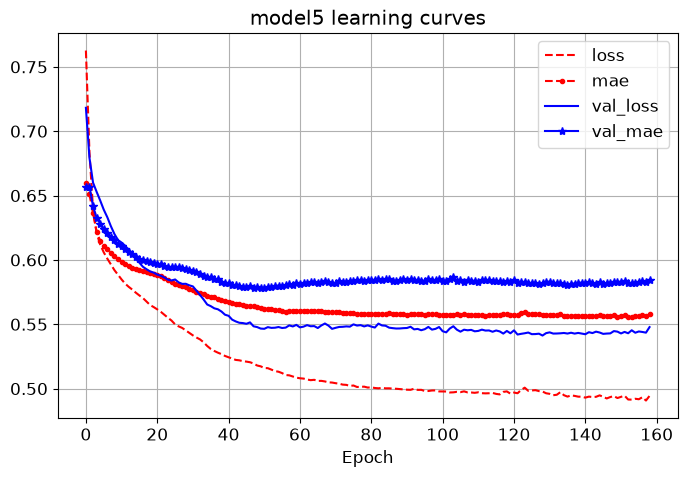

In [35]:
pd.DataFrame(history5.history).plot(figsize=(8, 5), grid=True, xlabel="Epoch",
                                    style=["r--", "r--.", "b-", "b-*"],
                                    title="model5 learning curves")
plt.show()

In [36]:
quality_scores.append(evaluate_quality_model(model5, "model5 (4 ReLU + 4 tanh)"))
quality_scores[-1]

{'model': 'model5 (4 ReLU + 4 tanh)',
 'train MSE': 0.49012210965156555,
 'train MAE': 0.5548324584960938,
 'validation MSE': 0.5412595272064209,
 'validation MAE': 0.5818530917167664}

### 11. Task 2: model6, All tanh

In [37]:
tf.random.set_seed(42)

model6 = tf.keras.Sequential([tf.keras.layers.InputLayer(shape=[11])])
for _ in range(8):
    model6.add(tf.keras.layers.Dense(5, activation="tanh"))
model6.add(tf.keras.layers.Dense(1, activation="tanh"))
model6.add(tf.keras.layers.Rescaling(scale=3.0, offset=6.0))

history6 = fit_quality_model(model6)
print("epochs actually run:", len(history6.history["loss"]))

I0000 00:00:1786365446.015918  419851 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_227347__.15


I0000 00:00:1786365446.998503  419848 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_227347__.15


epochs actually run: 81


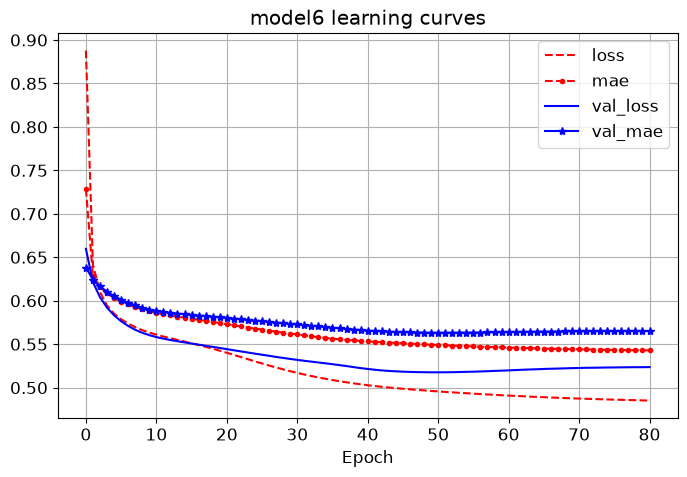

In [38]:
pd.DataFrame(history6.history).plot(figsize=(8, 5), grid=True, xlabel="Epoch",
                                    style=["r--", "r--.", "b-", "b-*"],
                                    title="model6 learning curves")
plt.show()

### 12. Task 2: Comparison

In [39]:
quality_scores.append(evaluate_quality_model(model6, "model6 (8 tanh)"))
pd.DataFrame(quality_scores).set_index("model").round(4)

,train MSE,train MAE,validation MSE,validation MAE
model,,,,
model4 (8 ReLU),0.7864,0.6720,0.7755,0.6746
model5 (4 ReLU + 4 tanh),0.4901,0.5548,0.5413,0.5819
model6 (8 tanh),0.4909,0.5495,0.5176,0.5631


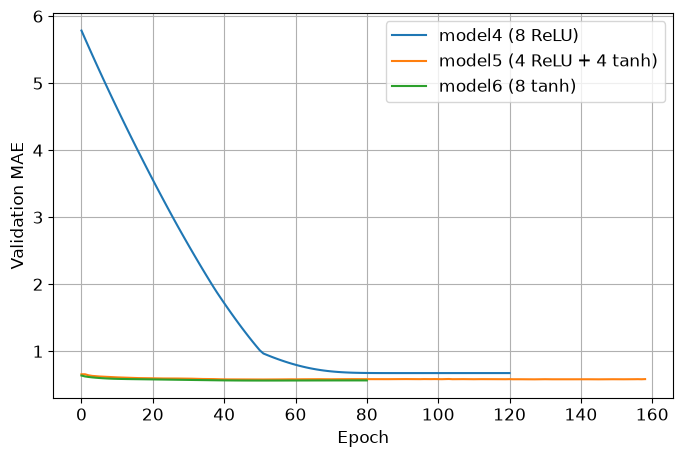

In [40]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, history in [("model4 (8 ReLU)", history4),
                      ("model5 (4 ReLU + 4 tanh)", history5),
                      ("model6 (8 tanh)", history6)]:
    ax.plot(history.history["val_mae"], label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation MAE")
ax.grid(True)
ax.legend()
plt.show()

The three regression models come out in the order the lab sheet predicts.

`model4`, with 8 ReLU hidden layers, is clearly the weakest at 0.775 validation MSE and
0.675 MAE. Eight layers of only 5 neurons is a long narrow stack, and ReLU makes that
worse: any unit driven negative stops passing gradient, and losing even one of 5 units in a
layer is a large fraction of that layer's capacity.

`model5` swapping the last 4 hidden layers and the output to tanh drops validation MSE to
0.541 and MAE to 0.582. tanh saturates but never dies, so the narrow layers keep passing
signal. The `Rescaling` layer also helps by construction: tanh emits $[-1, 1]$ and the
rescaling maps that onto $[3, 9]$, so the model starts out predicting in the right range
and only has to learn the shape of the response, not its offset.

`model6`, with all 8 hidden layers on tanh, gives the further small gain the sheet mentions,
at 0.518 MSE and 0.563 MAE. An MAE of 0.56 means a typical prediction is within about half
a quality point, which is reasonable given the scores are integers and the raters
themselves would not agree much more closely than that.